In [3]:
import pandas as pd
import os

In [4]:
df = pd.read_csv("../data/raw/Gaming_Academic_Performance.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


    Features Included:
    Gaming hours, study hours, sleep hours
    Reaction time (cognitive performance)
    Stress levels
    Attendance and device usage
    Academic grades (target variable)

In [6]:
df.sample(10)

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
4049,4050,16,Male,3.64,6.98,7.71,80.38,Casual,1.01,6.07,285.46,10.89,Medium,74.000000
2446,2447,23,Female,5.53,7.65,8.97,79.38,FPS,3.40,9.27,239.06,11.29,Low,105.351459
1280,1281,18,Female,4.93,6.97,8.11,69.67,RPG,2.31,9.01,260.84,12.52,Medium,81.301265
2026,2027,20,Female,6.41,4.25,7.66,75.30,FPS,0.57,12.21,230.95,16.37,Low,47.570000
7439,7440,20,Male,3.45,9.93,4.31,96.83,Casual,3.37,8.13,284.43,3.58,High,100.000000
4516,4517,17,Male,5.49,1.08,7.95,67.43,RPG,4.06,11.30,249.10,14.03,Low,44.900000
6960,6961,16,Male,1.59,4.32,6.59,66.75,RPG,4.42,5.86,292.35,9.36,Medium,67.600000
6193,6194,24,Female,6.40,5.97,4.74,74.32,FPS,2.81,11.01,255.51,14.75,Low,36.050000
594,595,20,Female,3.35,2.31,4.17,64.22,Casual,2.54,5.08,282.15,11.86,Medium,38.600000
2923,2924,21,Male,7.60,8.40,5.90,98.62,FPS,4.91,10.25,226.46,14.44,High,78.156492


## **Handling Missing Values**

In [7]:
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

    There is no any missing values in any columns 

## **Encoding**

    There are 2 columns that can be encoded with one-hot encoding and a column with ordinal encoding 

In [8]:
one_hot_columns = ["gender", "gaming_genre"]

for col in df[one_hot_columns]:
    dummies = pd.get_dummies(df[col], prefix=col, dtype=int)
    df = pd.concat([df.drop(columns=[col]), dummies], axis=1)


stress_level_mapping = {
    "Low" : 0,
    "Medium" : 1,
    "High" : 2
}

df["stress_level"] = df["stress_level"].map(stress_level_mapping)

In [9]:
df.sample(10)

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gender_Female,gender_Male,gender_Other,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG
1663,1664,17,3.08,7.28,7.74,94.87,3.70,5.26,282.17,8.86,1,97.210000,0,1,0,1,0,0
7875,7876,17,0.47,4.01,5.54,82.40,4.17,2.45,326.14,-0.62,1,80.210807,1,0,0,0,1,0
520,521,21,7.82,5.15,4.38,97.10,1.15,10.09,225.31,15.15,0,31.070000,0,1,0,1,0,0
1680,1681,16,7.75,7.58,4.60,90.22,3.03,12.97,219.09,20.83,2,61.227763,0,1,0,1,0,0
3757,3758,18,3.50,8.39,7.19,79.03,4.49,6.06,288.82,9.73,1,98.140000,0,1,0,0,1,0
2298,2299,20,1.95,1.30,8.40,63.66,3.15,6.10,292.28,4.81,1,58.040000,0,1,0,0,1,0
7897,7898,22,7.51,1.99,6.41,80.60,2.96,11.02,236.50,16.33,0,22.980000,0,1,0,1,0,0
3864,3865,22,5.15,7.36,8.35,91.12,4.58,10.50,260.03,10.98,0,84.586444,1,0,0,0,0,1
4480,4481,19,1.31,3.74,4.79,83.38,2.84,5.80,304.20,2.05,1,67.510000,0,1,0,0,0,1
1254,1255,21,5.24,1.62,6.47,80.84,1.41,7.67,274.54,10.86,0,36.930000,0,1,0,1,0,0


    Encoded dataset is needed to be saved to a separate folder

In [10]:
output_folder = "../data/preprocessed"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "encoded_df.csv")
df.to_csv(output_path, index=False)


## **Model selection**

    There algorithms that require scaling and there also are algorithms that do not require scaling.

    Requires scaling!!!

    Linear Regression 
    Ridge Regression 
    Lasso Regression 
    SVM 

    Do not require scaling 

    Decision tree
    Random Forest

In [11]:
df.sample(1)

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gender_Female,gender_Male,gender_Other,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG
2338,2339,20,7.86,7.81,8.42,70.5,2.54,10.47,231.47,18.2,0,66.437089,0,1,0,0,0,1


In [13]:
from sklearn.model_selection import train_test_split

x = df.drop("grades", axis=1)
y = df["grades"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

## **Linear Regression**

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

linear_model = LinearRegression()
linear_model.fit(x_train_scaled, y_train)

y_pred = linear_model.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

5.508086621015127
48.54585336353563
6.967485440496853
0.903150528197956


## **Ridge Regression**

In [17]:
from sklearn.linear_model import Ridge

rm = Ridge(alpha=0.01)

rm.fit(x_train_scaled, y_train)

y_pred = rm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

5.510206350662008
48.566473591616486
6.968965030161687
0.9031093906329593


## **Lasso Regression**

In [18]:
from sklearn.linear_model import Lasso

lm = Lasso(alpha=1)

lm.fit(x_train_scaled, y_train)

y_pred = lm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

5.733299356746154
52.47019368424159
7.2436312498802415
0.8953214292966414


## **SVM**

In [19]:
from sklearn.svm import SVR

svm = SVR(
    kernel="rbf",    
    C=1.0,            
    gamma="scale",    
    epsilon=0.1       
)

svm.fit(x_train_scaled, y_train)

y_pred = svm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

5.715689432762617
55.55052444450227
7.453222420168492
0.8891761380629535


## **Working with models that do not require scaling**

## **Decision Tree Regressor**

In [20]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

6.944728488222774
79.8951834605993
8.93841056679538
0.8406082954244953


## **Random Forest**

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

4.875133154681223
39.670756231445765
6.298472531610006
0.9208564373514734


## **K-fold cross validation**

In [25]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(rf,x,y,cv=kf,scoring=mae)
print(-scores)

0.926634564441839
[4.86845231 4.6015174  4.57751418 4.77169463 4.86405876]


## **Comparing algorithm results**

In [22]:
from tabulate import tabulate

columns = ["Algorithm", "Mean Absolute Error", "Mean Squared Error", "Root Mean Squared Error", "R2_score"]

results = [["Linear Regression", 5.508, 48.54, 6.96, 0.90],
           ["Ridge Model", 5.51, 48.56, 6.96, 0.90],
           ["Lasso Model", 5.73, 52.47, 7.24, 0.89],
           ["SVM", 5.71, 55.55, 7.45, 0.88],
           ["Decision Tree Regressor", 6.94,79.89, 8.93, 0.84],
           ["Random Forest Regressor", 4.87, 39.67, 6.29,  0.92]]

table = tabulate(results, headers = columns, tablefmt = 'grid', floatfmt='.2f')
print(table)

+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Algorithm               |   Mean Absolute Error |   Mean Squared Error |   Root Mean Squared Error |   R2_score |
+=========================+=======================+======================+===========================+============+
| Linear Regression       |                  5.51 |                48.54 |                      6.96 |       0.90 |
+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Ridge Model             |                  5.51 |                48.56 |                      6.96 |       0.90 |
+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Lasso Model             |                  5.73 |                52.47 |                      7.24 |       0.89 |
+-------------------------+-----------------------+---------------------

    It is clear from the table that Random Forest Regressor is the best with this dataset.

## **Visualisation**

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

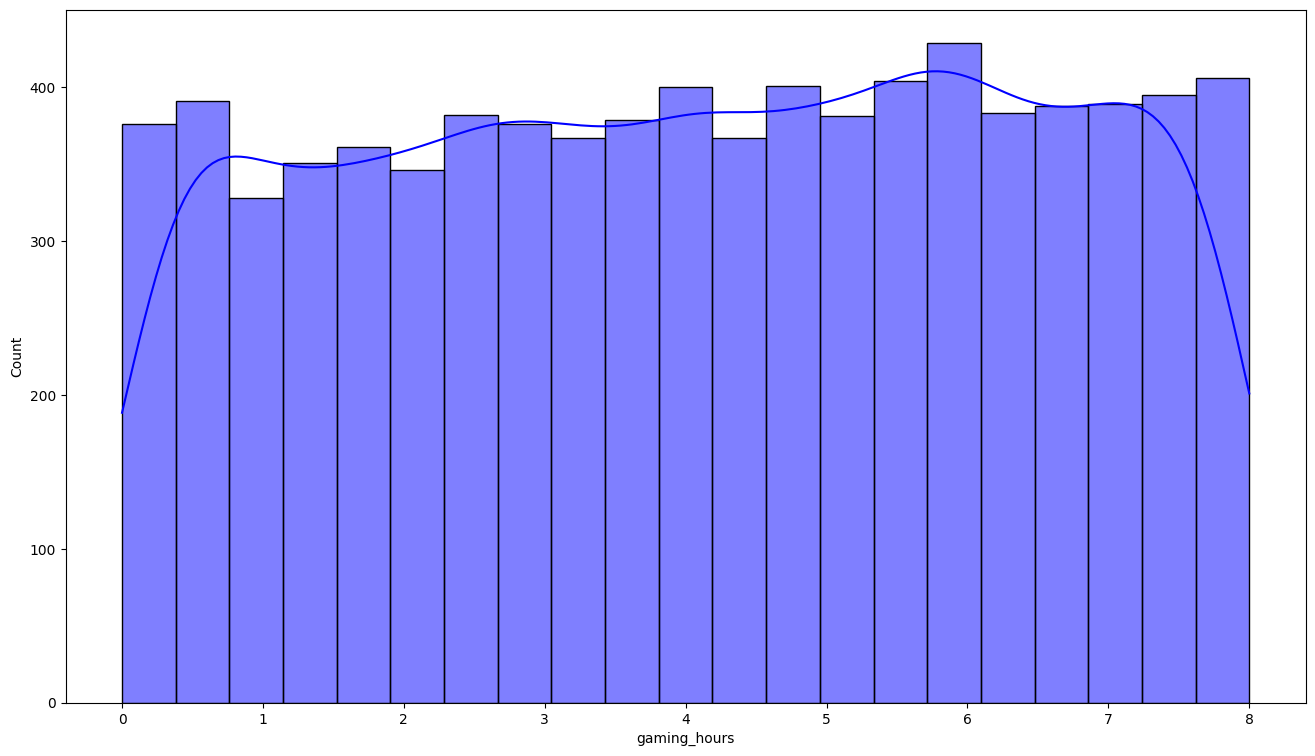

In [31]:
plt.figure(figsize=(16,9))
sns.histplot(df["gaming_hours"],kde=True, color="blue")
plt.show()

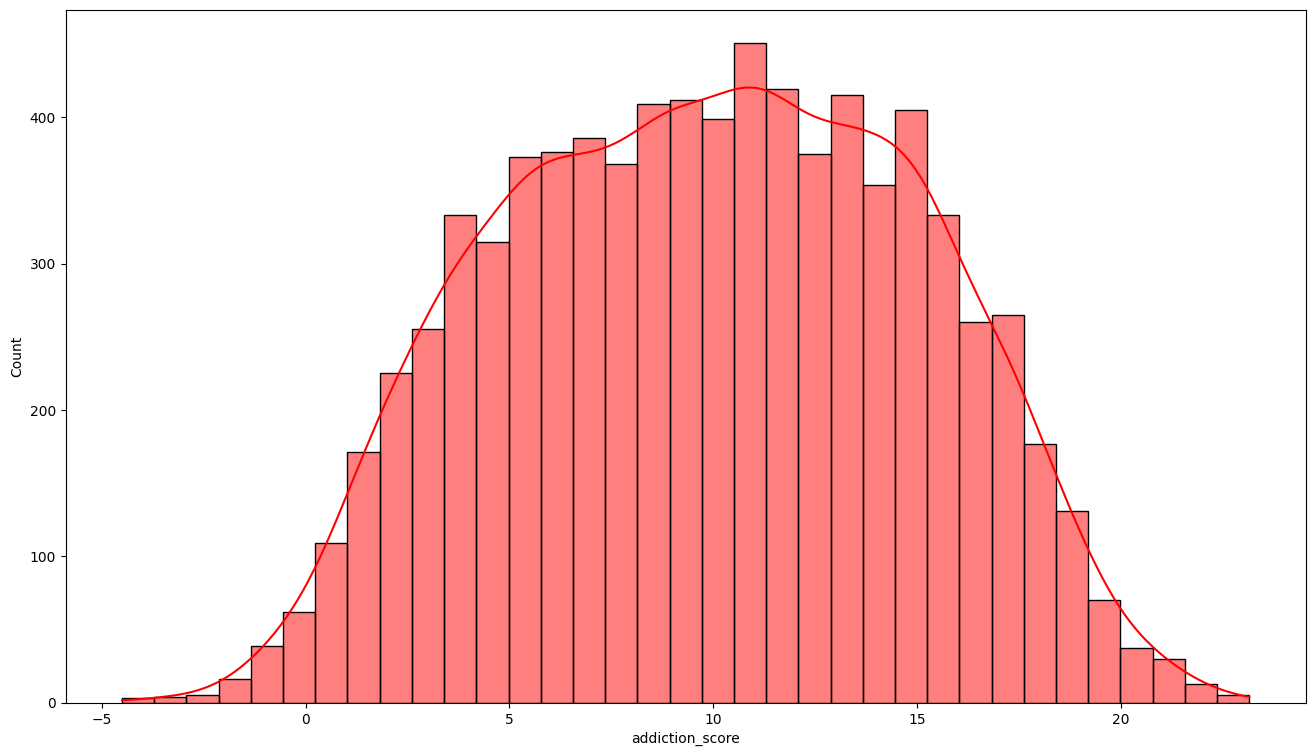

In [33]:
plt.figure(figsize=(16,9))
sns.histplot(df["addiction_score"], kde=True, color="red")
plt.show()

array([[<Axes: title={'center': 'gaming_hours'}>,
        <Axes: title={'center': 'study_hours'}>],
       [<Axes: title={'center': 'sleep_hours'}>,
        <Axes: title={'center': 'grades'}>]], dtype=object)

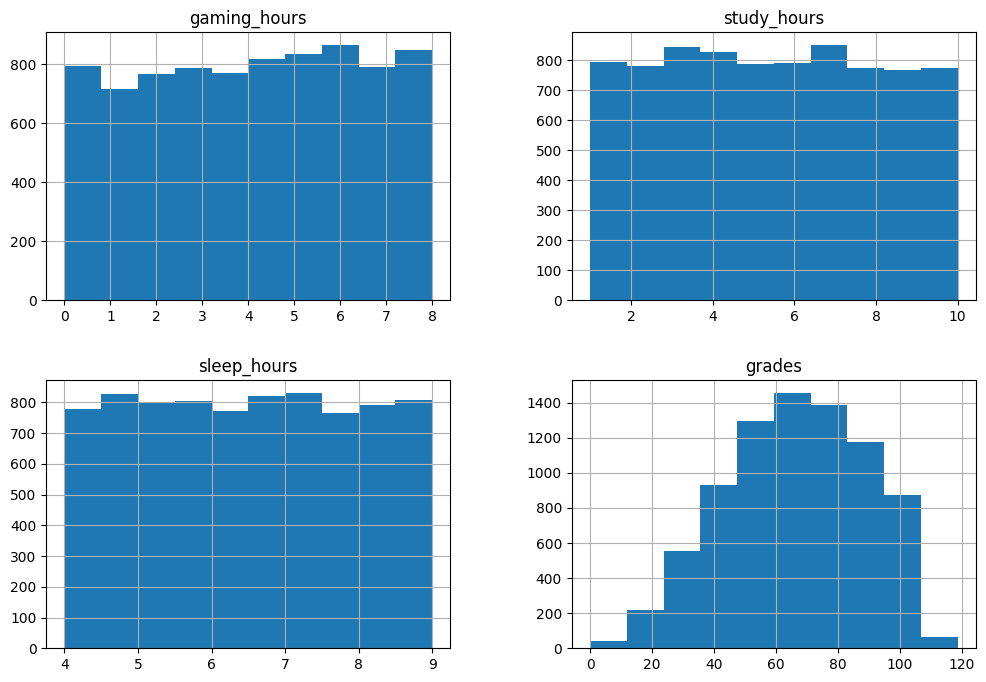

In [34]:
df[["gaming_hours", "study_hours", "sleep_hours", "grades"]].hist(figsize=(12,8))

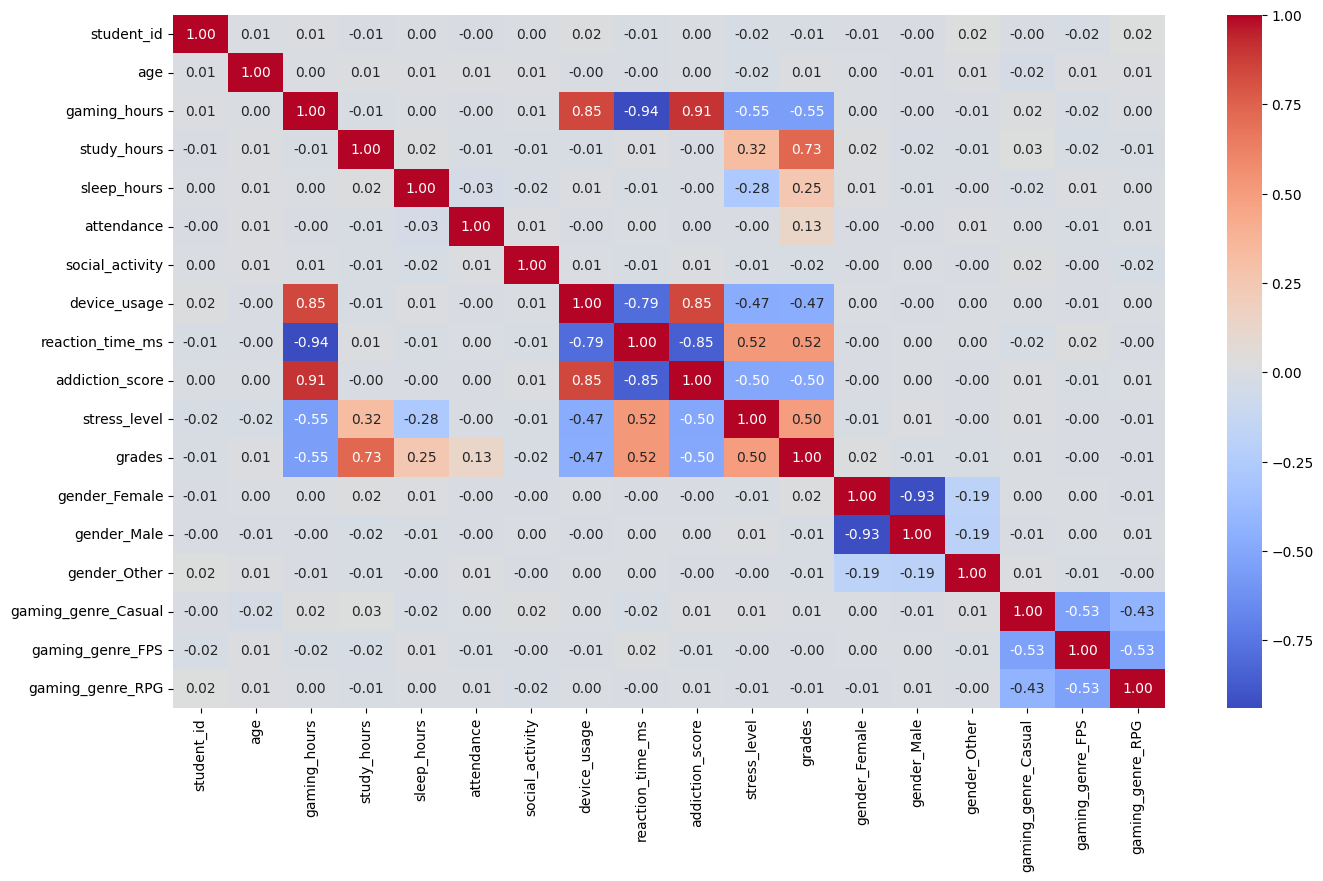

In [38]:
plt.figure(figsize=(16,9))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

<Axes: xlabel='gaming_hours', ylabel='grades'>

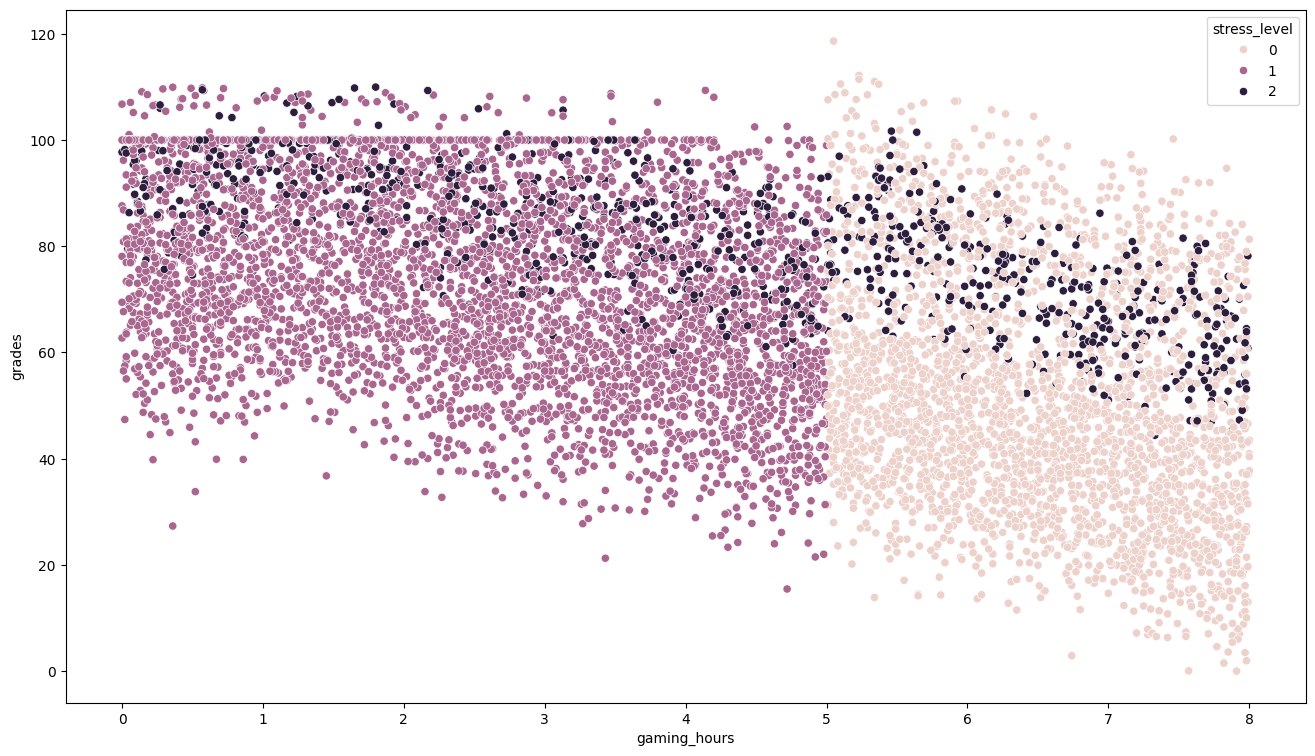

In [40]:
# Gaming hours vs grades
plt.figure(figsize=(16,9))
sns.scatterplot(data=df, x="gaming_hours", y="grades", hue="stress_level")

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           8000 non-null   int64  
 1   age                  8000 non-null   int64  
 2   gaming_hours         8000 non-null   float64
 3   study_hours          8000 non-null   float64
 4   sleep_hours          8000 non-null   float64
 5   attendance           8000 non-null   float64
 6   social_activity      8000 non-null   float64
 7   device_usage         8000 non-null   float64
 8   reaction_time_ms     8000 non-null   float64
 9   addiction_score      8000 non-null   float64
 10  stress_level         8000 non-null   int64  
 11  grades               8000 non-null   float64
 12  gender_Female        8000 non-null   int32  
 13  gender_Male          8000 non-null   int32  
 14  gender_Other         8000 non-null   int32  
 15  gaming_genre_Casual  8000 non-null   i

## **Feature engineering**

In [43]:
df["total_screen_hours"] = df["gaming_hours"] + df["device_usage"]

In [45]:
df["free_time"] = 24 - df["study_hours"] - df["sleep_hours"] - df["gaming_hours"]

In [47]:
df["gaming_study_ratio"] = df["gaming_hours"] / (df["study_hours"] + 1)

**Feature engineered dataset needs to be added into new folder**

In [49]:
output_folder = "../data/engineered"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "encoded_df.csv")
df.to_csv(output_path, index=False)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           8000 non-null   int64  
 1   age                  8000 non-null   int64  
 2   gaming_hours         8000 non-null   float64
 3   study_hours          8000 non-null   float64
 4   sleep_hours          8000 non-null   float64
 5   attendance           8000 non-null   float64
 6   social_activity      8000 non-null   float64
 7   device_usage         8000 non-null   float64
 8   reaction_time_ms     8000 non-null   float64
 9   addiction_score      8000 non-null   float64
 10  stress_level         8000 non-null   int64  
 11  grades               8000 non-null   float64
 12  gender_Female        8000 non-null   int32  
 13  gender_Male          8000 non-null   int32  
 14  gender_Other         8000 non-null   int32  
 15  gaming_genre_Casual  8000 non-null   i

## **Linear Regression**

In [52]:

x = df.drop("grades", axis=1)
y = df["grades"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

linear_model = LinearRegression()
linear_model.fit(x_train_scaled, y_train)

y_pred = linear_model.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

5.436609231923764
47.30264237244881
6.877691645635824
0.9056307467847755


## **K-fold cross validation**

In [53]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(linear_model, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(rf,x,y,cv=kf,scoring=mae)
print(-scores)

0.9143050791338423
[4.77544538 4.52127701 4.4991664  4.57414255 4.67216227]


## **Ridge Regression**

In [54]:

rm = Ridge(alpha=0.01)

rm.fit(x_train_scaled, y_train)

y_pred = rm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

5.435028900880514
47.292201273746976
6.876932548291205
0.9056515768830072


## **Lasso Regression**

In [55]:
lm = Lasso(alpha=1)

lm.fit(x_train_scaled, y_train)

y_pred = lm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

5.657701859559165
51.49216156322827
7.17580389665355
0.8972726133373513


## **SVM**

In [58]:
svm = SVR(
    kernel="rbf",    
    C=1.0,            
    gamma="scale",    
    epsilon=0.1       
)

svm.fit(x_train_scaled, y_train)

y_pred = svm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

5.5439956253537
51.72421493142166
7.191954875513448
0.8968096645048091


## **Algorithms that do not require scaling**

## **Decision Tree Regressor**

In [59]:
dt = DecisionTreeRegressor()

dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

6.800712086555615
75.6111570294844
8.695467614193293
0.8491549717787548


## **RandomForest Regressor**

In [60]:
rf = RandomForestRegressor()

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

4.780331784993426
37.9065940711964
6.156833120297837
0.9243759588256111


In [61]:
from tabulate import tabulate

columns = ["Algorithm", "Mean Absolute Error", "Mean Squared Error", "Root Mean Squared Error", "R2_score"]

results = [["Linear Regression", 5.43, 47.30, 6.87, 0.90],
           ["Ridge Model", 5.43, 47.29, 6.87, 0.90],
           ["Lasso Model", 5.65, 51.49, 7.17, 0.89],
           ["SVM", 5.54, 51.72, 7.19, 0.89],
           ["Decision Tree Regressor", 6.80,75.61, 8.69, 0.84],
           ["Random Forest Regressor", 4.78, 37.90, 6.15,  0.92]]

table = tabulate(results, headers = columns, tablefmt = 'grid', floatfmt='.2f')
print(table)

+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Algorithm               |   Mean Absolute Error |   Mean Squared Error |   Root Mean Squared Error |   R2_score |
+=========================+=======================+======================+===========================+============+
| Linear Regression       |                  5.43 |                47.30 |                      6.87 |       0.90 |
+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Ridge Model             |                  5.43 |                47.29 |                      6.87 |       0.90 |
+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Lasso Model             |                  5.65 |                51.49 |                      7.17 |       0.89 |
+-------------------------+-----------------------+---------------------

    The difference in metrics can be seen in tables before and after feature engineering

    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Algorithm               |   Mean Absolute Error |   Mean Squared Error |   Root Mean Squared Error |   R2_score |
    +=========================+=======================+======================+===========================+============+
    | Linear Regression       |                  5.51 |                48.54 |                      6.96 |       0.90 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Ridge Model             |                  5.51 |                48.56 |                      6.96 |       0.90 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Lasso Model             |                  5.73 |                52.47 |                      7.24 |       0.89 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | SVM                     |                  5.71 |                55.55 |                      7.45 |       0.88 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Decision Tree Regressor |                  6.94 |                79.89 |                      8.93 |       0.84 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Random Forest Regressor |                  4.87 |                39.67 |                      6.29 |       0.92 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+